# Loan Default Prediction Model
End-to-end pipeline: load → clean → feature engineer → train → evaluate → save

## 1. Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import lightgbm as lgb

pd.set_option('display.max_columns', 50)
SEED = 42
DATA_PATH = 'loan.csv'
print('Libraries loaded OK')

Libraries loaded OK


## 2. Load Data

In [2]:
t0 = time.time()
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded in {time.time()-t0:.1f}s  |  shape: {df_raw.shape}')
df_raw['loan_status'].value_counts()

Loaded in 214.7s  |  shape: (2260668, 145)


loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

## 3. Define Target — Binary Default Flag

In [3]:
# Keep only closed loans — exclude 'Current' since outcome is unknown
KEEP_STATUSES = {
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Late (31-120 days)': 1,
    'Late (16-30 days)': 1,
    'Does not meet the credit policy. Status:Charged Off': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'In Grace Period': 1,  # treat as at-risk
}

df = df_raw[df_raw['loan_status'].isin(KEEP_STATUSES)].copy()
df['default'] = df['loan_status'].map(KEEP_STATUSES)

print(f'Rows after filtering: {len(df):,}')
print(f"Default rate: {df['default'].mean():.2%}")
df['default'].value_counts()

Rows after filtering: 1,340,973
Default rate: 22.15%


default
0    1043940
1     297033
Name: count, dtype: int64

## 4. Feature Selection — Avoid Data Leakage

In [4]:
# Only use features available AT LOAN ORIGINATION — no post-loan payment data
# Drop: out_prncp, total_pymnt, recoveries, last_pymnt*, total_rec_*, settlement_*, hardship_*, etc.

FEATURES = [
    # Loan characteristics
    'loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment',
    'grade', 'sub_grade', 'purpose', 'initial_list_status',
    # Borrower profile
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'addr_state',
    # Credit history
    'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
    'mths_since_last_delinq', 'mths_since_last_record',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    # Extended credit metrics (newer features)
    'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',
    'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl',
    'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl',
    'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0',
    'num_sats', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
    'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
    'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort',
    'total_bc_limit', 'total_il_high_credit_limit', 'total_rev_hi_lim',
]

# Keep only columns that exist in df
FEATURES = [f for f in FEATURES if f in df.columns]
print(f'Using {len(FEATURES)} features')

Using 57 features


## 5. Feature Engineering

In [5]:
df2 = df[FEATURES + ['default']].copy()

# -- term: '36 months' → 36
df2['term'] = df2['term'].str.extract(r'(\d+)').astype(float)

# -- int_rate: '15.02%' → 15.02
if df2['int_rate'].dtype == object:
    df2['int_rate'] = df2['int_rate'].str.replace('%','').astype(float)

# -- revol_util: '73.2%' → 73.2
if df2['revol_util'].dtype == object:
    df2['revol_util'] = df2['revol_util'].str.replace('%','').astype(float)

# -- emp_length: '10+ years' → 10, '< 1 year' → 0
def parse_emp(s):
    if pd.isna(s): return np.nan
    if '10+' in str(s): return 10
    if '< 1' in str(s): return 0
    digits = ''.join(filter(str.isdigit, str(s)))
    return int(digits) if digits else np.nan

df2['emp_length'] = df2['emp_length'].apply(parse_emp)

# -- earliest_cr_line → credit age in months from 2020
df2['cr_line_age_mths'] = pd.to_datetime(df2['earliest_cr_line'], errors='coerce')
df2['cr_line_age_mths'] = ((pd.Timestamp('2020-01-01') - df2['cr_line_age_mths'])
                            .dt.days / 30).round(1)
df2.drop(columns=['earliest_cr_line'], inplace=True)

# -- Derived ratios
df2['loan_to_income']     = df2['loan_amnt'] / (df2['annual_inc'] + 1)
df2['installment_to_inc'] = df2['installment'] / (df2['annual_inc'] / 12 + 1)

# -- Encode ordinals
GRADE_MAP = {'A':7,'B':6,'C':5,'D':4,'E':3,'F':2,'G':1}
df2['grade_num'] = df2['grade'].map(GRADE_MAP)

# -- Low-cardinality categoricals → LabelEncoder
CAT_COLS = ['home_ownership','verification_status','purpose',
            'initial_list_status','sub_grade','addr_state']
CAT_COLS = [c for c in CAT_COLS if c in df2.columns]

le = LabelEncoder()
for col in CAT_COLS:
    df2[col] = df2[col].fillna('MISSING')
    df2[col] = le.fit_transform(df2[col].astype(str))

# Drop original grade (replaced by grade_num)
df2.drop(columns=['grade'], inplace=True, errors='ignore')

print('Feature engineering done')
print(f'Final shape: {df2.shape}')
df2.head(3)

Feature engineering done
Final shape: (1340973, 60)


,loan_amnt,funded_amnt,term,int_rate,installment,sub_grade,purpose,initial_list_status,emp_length,home_ownership,annual_inc,verification_status,addr_state,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,acc_open_past_24mths,avg_cur_bal,...,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,total_rev_hi_lim,default,cr_line_age_mths,loan_to_income,installment_to_inc,grade_num
100,30000,30000,36.0,22.35,1151.16,19,2,1,5.0,1,100000.0,1,4,30.46,0.0,0.0,51.0,84.0,11.0,1.0,15603,37.0,19.0,4.0,42939.0,...,3.0,4.0,3.0,5.0,10.0,6.0,8.0,4.0,11.0,0.0,2.0,89.5,33.3,1.0,0.0,527120.0,98453.0,28600.0,101984.0,42200.0,0,97.4,0.299997,0.138123,4
152,40000,40000,60.0,16.14,975.71,13,1,1,0.0,1,45000.0,2,35,50.53,0.0,0.0,NaN,NaN,18.0,0.0,34971,64.5,37.0,5.0,15059.0,...,7.0,9.0,7.0,7.0,26.0,9.0,10.0,9.0,18.0,0.0,4.0,100.0,42.9,0.0,0.0,344802.0,161720.0,45700.0,167965.0,54200.0,0,128.9,0.888869,0.260120,5
170,20000,20000,36.0,7.56,622.68,2,1,1,10.0,1,100000.0,0,47,18.92,0.0,0.0,48.0,NaN,9.0,0.0,25416,29.9,19.0,5.0,57309.0,...,5.0,5.0,5.0,6.0,5.0,5.0,9.0,5.0,9.0,0.0,1.0,94.7,20.0,0.0,0.0,622183.0,71569.0,85100.0,74833.0,85100.0,0,254.6,0.199998,0.074713,7


## 6. Missing Value Overview

In [6]:
miss = df2.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print(f'{len(miss)} columns with missing values:')
print(miss.head(20).to_string())

# Drop columns with >50% missing
high_miss = miss[miss > 0.5].index.tolist()
print(f'\nDropping {len(high_miss)} columns with >50% missing: {high_miss}')
df2.drop(columns=high_miss, inplace=True)

46 columns with missing values:
mths_since_last_record    0.829352
mths_since_last_delinq    0.503395
mths_since_recent_inq     0.130704
mo_sin_old_il_acct        0.080720
emp_length                0.058486
pct_tl_nvr_dlq            0.052522
avg_cur_bal               0.052424
num_rev_accts             0.052407
mo_sin_rcnt_rev_tl_op     0.052407
mo_sin_old_rev_tl_op      0.052407
num_op_rev_tl             0.052407
num_il_tl                 0.052407
num_actv_rev_tl           0.052407
num_actv_bc_tl            0.052407
num_accts_ever_120_pd     0.052407
num_rev_tl_bal_gt_0       0.052407
num_tl_90g_dpd_24m        0.052407
num_tl_op_past_12m        0.052407
num_bc_tl                 0.052407
mo_sin_rcnt_tl            0.052407

Dropping 2 columns with >50% missing: ['mths_since_last_record', 'mths_since_last_delinq']


## 7. Train / Validation / Test Split

In [7]:
X = df2.drop(columns=['default'])
y = df2['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

print(f'Train: {X_train.shape[0]:,}  Val: {X_val.shape[0]:,}  Test: {X_test.shape[0]:,}')
print(f'Default rate — Train: {y_train.mean():.2%}  Val: {y_val.mean():.2%}  Test: {y_test.mean():.2%}')

Train: 911,861  Val: 160,917  Test: 268,195
Default rate — Train: 22.15%  Val: 22.15%  Test: 22.15%


## 8. Train LightGBM Model

In [8]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'class_weight': 'balanced',
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1,
}

model = lgb.LGBMClassifier(**params)

t0 = time.time()
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)
print(f'\nTraining time: {time.time()-t0:.1f}s')
print(f'Best iteration: {model.best_iteration_}')

[100]	valid_0's auc: 0.72574


[200]	valid_0's auc: 0.733659


[300]	valid_0's auc: 0.73667


[400]	valid_0's auc: 0.737883


[500]	valid_0's auc: 0.73856


[600]	valid_0's auc: 0.738942


[700]	valid_0's auc: 0.739293


[800]	valid_0's auc: 0.739375


[900]	valid_0's auc: 0.739504


[1000]	valid_0's auc: 0.739635

Training time: 47.8s
Best iteration: 988


## 9. Evaluate on Test Set

In [9]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

print(f'ROC-AUC:           {roc_auc:.4f}')
print(f'Avg Precision:     {avg_prec:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Default','Default']))

ROC-AUC:           0.7401
Avg Precision:     0.4476

              precision    recall  f1-score   support

  No Default       0.88      0.67      0.76    208788
     Default       0.37      0.68      0.48     59407

    accuracy                           0.67    268195
   macro avg       0.63      0.67      0.62    268195
weighted avg       0.77      0.67      0.70    268195



## 10. ROC & Precision-Recall Curves

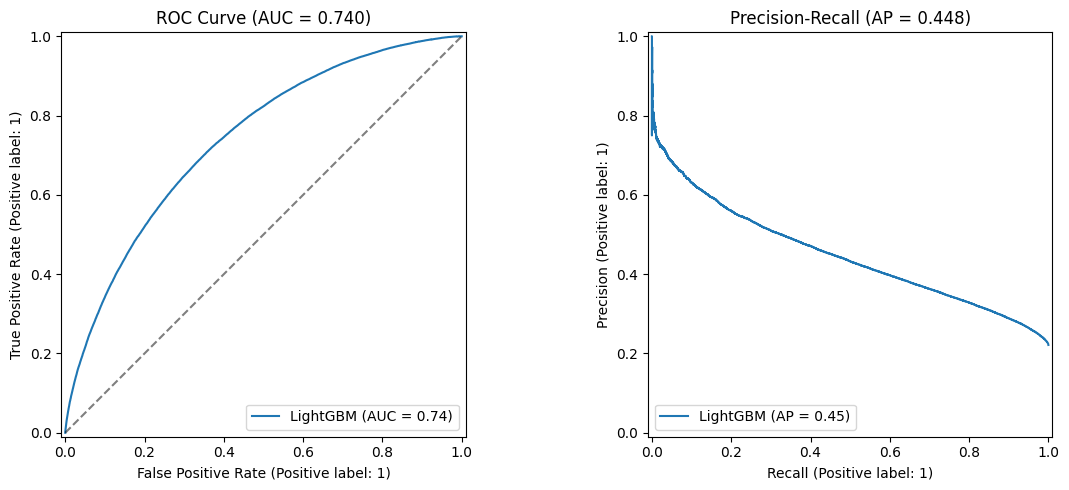

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name='LightGBM')
axes[0].set_title(f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.5)

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name='LightGBM')
axes[1].set_title(f'Precision-Recall (AP = {avg_prec:.3f})')

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Confusion Matrix

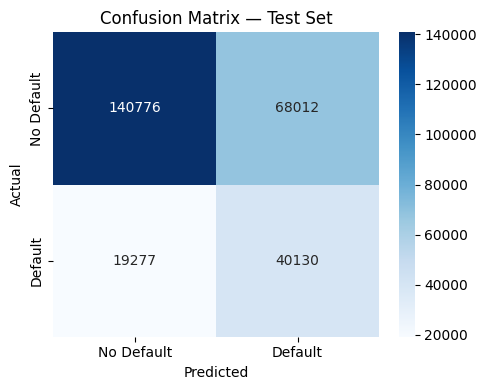

In [11]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default','Default'],
            yticklabels=['No Default','Default'], ax=ax)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Feature Importance

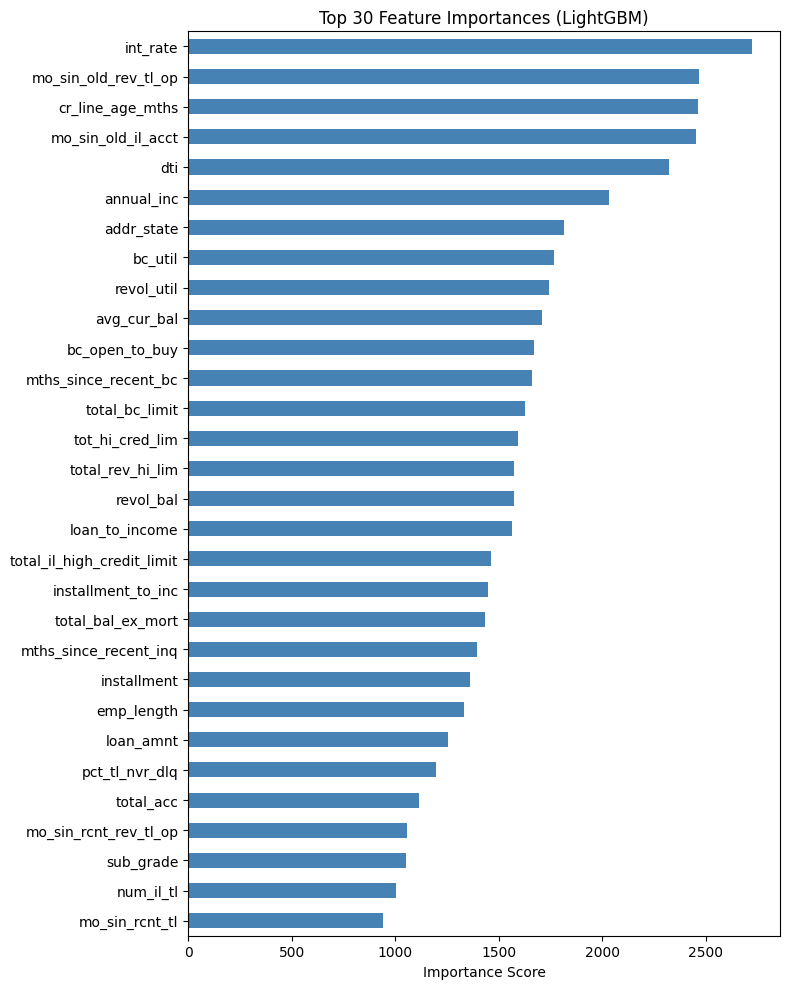


Top 10:
int_rate                2722
mo_sin_old_rev_tl_op    2466
cr_line_age_mths        2462
mo_sin_old_il_acct      2452
dti                     2323
annual_inc              2030
addr_state              1814
bc_util                 1768
revol_util              1743
avg_cur_bal             1707


In [12]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
top30 = importances.nlargest(30).sort_values()

fig, ax = plt.subplots(figsize=(8, 10))
top30.plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 30 Feature Importances (LightGBM)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10:')
print(importances.nlargest(10).to_string())

## 13. Default Risk Score Distribution

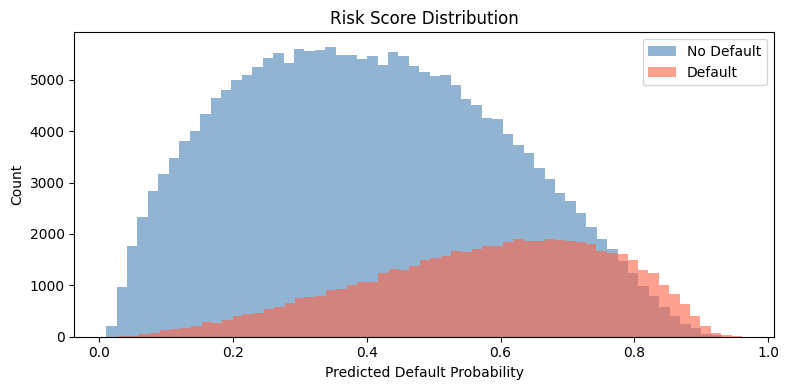

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_prob[y_test == 0], bins=60, alpha=0.6, label='No Default', color='steelblue')
ax.hist(y_prob[y_test == 1], bins=60, alpha=0.6, label='Default',    color='tomato')
ax.set_xlabel('Predicted Default Probability')
ax.set_ylabel('Count')
ax.set_title('Risk Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Threshold Analysis — Precision vs Recall Tradeoff

Best F1 threshold: 0.518
  Precision: 0.382
  Recall:    0.645
  F1:        0.480


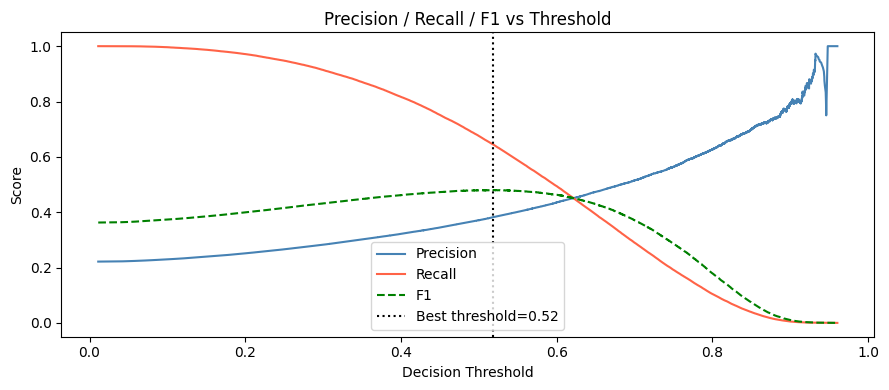

In [14]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print(f'Best F1 threshold: {best_threshold:.3f}')
print(f'  Precision: {precision[best_idx]:.3f}')
print(f'  Recall:    {recall[best_idx]:.3f}')
print(f'  F1:        {f1_scores[best_idx]:.3f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precision[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recall[:-1],    label='Recall',    color='tomato')
ax.plot(thresholds, f1_scores[:-1], label='F1',        color='green', linestyle='--')
ax.axvline(best_threshold, color='black', linestyle=':', label=f'Best threshold={best_threshold:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Predict on New Loans (Inference Example)

In [15]:
# Simulate inference on 5 test examples
sample = X_test.head(5).copy()
sample['actual_default']  = y_test.head(5).values
sample['default_prob']    = model.predict_proba(X_test.head(5))[:, 1].round(3)
sample['predicted_label'] = (sample['default_prob'] >= best_threshold).astype(int)
sample['risk_tier'] = pd.cut(
    sample['default_prob'],
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

display_cols = ['default_prob', 'predicted_label', 'actual_default', 'risk_tier']
sample[display_cols]

,default_prob,predicted_label,actual_default,risk_tier
1756019,0.399,0,0,Medium
1468608,0.611,1,1,Very High
529180,0.510,0,1,High
815387,0.577,1,1,High
1978702,0.325,0,0,Medium


## 16. Save Model & Artifacts

In [16]:
# Save the model
joblib.dump(model, 'loan_default_model.pkl')

# Save feature list so inference uses same columns
joblib.dump(list(X_train.columns), 'model_features.pkl')

# Save threshold
joblib.dump(best_threshold, 'best_threshold.pkl')

print('Saved:')
print('  loan_default_model.pkl')
print('  model_features.pkl')
print('  best_threshold.pkl')

# --- Quick reload test ---
loaded = joblib.load('loan_default_model.pkl')
feats  = joblib.load('model_features.pkl')
thresh = joblib.load('best_threshold.pkl')
prob   = loaded.predict_proba(X_test[feats].head(1))[:, 1][0]
print(f'\nReload test — prob on first test row: {prob:.3f}  (threshold: {thresh:.3f})')
print('Model ready for deployment.')

Saved:
  loan_default_model.pkl
  model_features.pkl
  best_threshold.pkl

Reload test — prob on first test row: 0.399  (threshold: 0.518)
Model ready for deployment.
